# Cut Lead Detection - Subtract Pipeline

Notebook implements binary `cut_lead` detection (cut_lead vs other classes) using:
1. small centroid alignment (translation only),
2. binary subtraction `ref - test`,
3. lead-zone masking,
4. connected-component filtering.

## 1. Set Up Environment and Imports
Import required packages and verify versions for reproducibility.

In [10]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import cv2
import matplotlib.pyplot as plt
import numpy as np

import model

plt.rcParams["figure.figsize"] = (12, 5)
print("opencv:", cv2.__version__)
print("numpy:", np.__version__)

opencv: 4.13.0
numpy: 2.4.4


## 2. Configure Project Parameters
Define paths and tunable thresholds in one place.

In [11]:
def find_project_dir(start: Path) -> Path:
    """Find directory containing transistor data and reference mask."""
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "transistor").exists() and (candidate / "reference_mask_vote_0.50.npy").exists():
            return candidate
    raise FileNotFoundError("Could not locate proj01 root.")

PROJECT_DIR = find_project_dir(Path.cwd())
TEST_DIR = PROJECT_DIR / "transistor" / "test"
REFERENCE_MASK_PATH = PROJECT_DIR / "reference_mask_vote_0.50.npy"

# Misplaced is intentionally excluded from evaluation scope.
EVAL_CLASS_NAMES = ["good", "bent_lead", "cut_lead", "damaged_case"]
TARGET_CLASS = "cut_lead"

MAX_ALIGNMENT_SHIFT_PX = 14
MIN_DEFECT_AREA_PX = 90
COMPONENT_MIN_AREA_PX = 20

LEAD_SIDE_FRACTION = 0.28
LEAD_TOP_FRACTION = 0.30
LEAD_BOTTOM_FRACTION = 1.00
LEAD_BOTTOM_BAND_TOP_FRACTION = 0.62

MORPH_CLOSE_KERNEL = 3
MORPH_OPEN_KERNEL = 3

REFERENCE_MASK = np.load(str(REFERENCE_MASK_PATH)).astype(np.uint8)
print("Project:", PROJECT_DIR)
print("Reference mask shape:", REFERENCE_MASK.shape)
print("Evaluation classes:", EVAL_CLASS_NAMES)

Project: C:\Users\MateuszOmen\Desktop\studia\sem6\zaawanasowane_algorytmy_wizyjne_projekty\Transformers\proj01
Reference mask shape: (1024, 1024)
Evaluation classes: ['good', 'bent_lead', 'cut_lead', 'damaged_case']


## 3. Load or Create Initial Input Data
Load one sample image for quick smoke checks before full evaluation.

Sample: cut_lead 000.png (1024, 1024, 3)


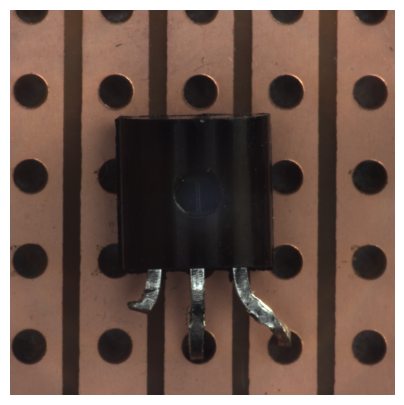

In [12]:
def load_rgb(path: Path) -> np.ndarray:
    """Load an image as RGB uint8."""
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def iter_test_images(test_dir: Path, class_names: list[str]) -> Iterable[tuple[str, Path]]:
    """Iterate through test images by class."""
    for cls_name in class_names:
        for img_path in sorted((test_dir / cls_name).glob("*.png")):
            yield cls_name, img_path

sample_cls = TARGET_CLASS
sample_path = next(iter((TEST_DIR / sample_cls).glob("*.png")), None)
if sample_path is None:
    raise FileNotFoundError(f"No sample image in {(TEST_DIR / sample_cls)}")

sample_img = load_rgb(sample_path)
print("Sample:", sample_cls, sample_path.name, sample_img.shape)
plt.imshow(sample_img)
plt.axis("off")
plt.show()

## 4. Implement Core Helper Functions
Utilities for mask normalization, centroid alignment, lead-zone creation, and connected-component cleanup.

In [13]:
def ensure_binary_mask(mask: np.ndarray) -> np.ndarray:
    """Convert mask to {0,255} uint8 format."""
    if mask.ndim != 2:
        raise ValueError("Mask must be 2D.")
    return ((mask > 0).astype(np.uint8) * 255)


def compute_centroid(mask: np.ndarray) -> tuple[float, float]:
    """Compute centroid of non-zero pixels."""
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return float("nan"), float("nan")
    return float(xs.mean()), float(ys.mean())


def shift_mask(mask: np.ndarray, dx: float, dy: float) -> np.ndarray:
    """Shift binary mask with nearest interpolation."""
    h, w = mask.shape
    matrix = np.array([[1.0, 0.0, dx], [0.0, 1.0, dy]], dtype=np.float32)
    shifted = cv2.warpAffine(mask, matrix, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)
    return ensure_binary_mask(shifted)


def cleanup_components(mask: np.ndarray, min_area: int) -> np.ndarray:
    """Remove connected components smaller than min_area."""
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for idx in range(1, n_labels):
        if int(stats[idx, cv2.CC_STAT_AREA]) >= int(min_area):
            out[labels == idx] = 255
    return out


def apply_morphology(mask: np.ndarray, operation: str, kernel_size: int) -> np.ndarray:
    """Apply light morphology to suppress edge artifacts and isolate stable regions."""
    binary = ensure_binary_mask(mask)
    k = int(max(1, kernel_size))
    if k <= 1:
        return binary
    if k % 2 == 0:
        k += 1
    kernel = np.ones((k, k), np.uint8)
    if operation == "close":
        return cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=1)
    if operation == "open":
        return cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    raise ValueError("operation must be 'close' or 'open'.")


def build_multi_zone_masks(
    reference_mask: np.ndarray,
    side_fraction: float,
    top_fraction: float,
    bottom_fraction: float,
    bottom_band_top_fraction: float,
    side_margin_px: int = 2,
    vertical_margin_px: int = 2,
) -> dict[str, np.ndarray]:
    """Build left/right lead zones and a bottom support zone from the reference mask bbox."""
    ref = ensure_binary_mask(reference_mask)
    ys, xs = np.where(ref > 0)
    if xs.size == 0:
        empty = np.zeros_like(ref)
        return {"left_lead": empty.copy(), "right_lead": empty.copy(), "bottom": empty.copy()}

    y_min, y_max = int(ys.min()), int(ys.max())
    x_min, x_max = int(xs.min()), int(xs.max())
    h, w = ref.shape

    span_x = max(1, x_max - x_min + 1)
    span_y = max(1, y_max - y_min + 1)
    side_width = max(1, int(round(side_fraction * span_x)))

    top_y = y_min + int(round(top_fraction * span_y))
    bottom_y = y_min + int(round(bottom_fraction * span_y))
    bottom_band_top_y = y_min + int(round(bottom_band_top_fraction * span_y))

    top_y = max(0, min(h - 1, top_y - vertical_margin_px))
    bottom_y = max(0, min(h - 1, bottom_y + vertical_margin_px))
    bottom_band_top_y = max(0, min(h - 1, bottom_band_top_y - vertical_margin_px))
    if bottom_y < top_y:
        bottom_y = top_y

    left_x0 = max(0, x_min - side_margin_px)
    left_x1 = min(w - 1, x_min + side_width + side_margin_px)
    right_x0 = max(0, x_max - side_width - side_margin_px)
    right_x1 = min(w - 1, x_max + side_margin_px)

    left_mask = np.zeros_like(ref)
    right_mask = np.zeros_like(ref)
    bottom_mask = np.zeros_like(ref)

    left_mask[top_y : bottom_y + 1, left_x0 : left_x1 + 1] = 255
    right_mask[top_y : bottom_y + 1, right_x0 : right_x1 + 1] = 255
    bottom_mask[bottom_band_top_y : bottom_y + 1, x_min : x_max + 1] = 255

    return {"left_lead": left_mask, "right_lead": right_mask, "bottom": bottom_mask}


def align_by_centroid_translation(
    ref_mask: np.ndarray,
    test_mask: np.ndarray,
    max_shift_px: Optional[int] = None,
) -> tuple[np.ndarray, dict]:
    """Align test mask to reference by centroid translation and optional shift clipping."""
    ref_bin = ensure_binary_mask(ref_mask)
    test_bin = ensure_binary_mask(test_mask)

    cx_ref, cy_ref = compute_centroid(ref_bin)
    cx_test, cy_test = compute_centroid(test_bin)

    debug = {
        "cx_ref": cx_ref,
        "cy_ref": cy_ref,
        "cx_test": cx_test,
        "cy_test": cy_test,
        "dx_raw": float("nan"),
        "dy_raw": float("nan"),
        "dx_used": float("nan"),
        "dy_used": float("nan"),
        "shift_clipped": False,
        "aligned": False,
        "reason": "ok",
    }

    if np.isnan(cx_ref) or np.isnan(cx_test):
        debug["reason"] = "empty_mask"
        return test_bin, debug

    dx_raw = cx_ref - cx_test
    dy_raw = cy_ref - cy_test
    dx_used = dx_raw
    dy_used = dy_raw

    if max_shift_px is not None:
        max_shift = float(max_shift_px)
        dx_used = float(np.clip(dx_raw, -max_shift, max_shift))
        dy_used = float(np.clip(dy_raw, -max_shift, max_shift))
        debug["shift_clipped"] = (abs(dx_used - dx_raw) > 1e-6) or (abs(dy_used - dy_raw) > 1e-6)

    debug["dx_raw"] = float(dx_raw)
    debug["dy_raw"] = float(dy_raw)
    debug["dx_used"] = float(dx_used)
    debug["dy_used"] = float(dy_used)

    aligned = shift_mask(test_bin, dx=dx_used, dy=dy_used)
    debug["aligned"] = True
    if debug["shift_clipped"]:
        debug["reason"] = "shift_clipped"
    return aligned, debug

## 5. Build the Main Execution Function
Detector uses alignment gate, subtraction, lead-zone masking, and area thresholding.

In [14]:
def is_cut_lead(
    image: np.ndarray,
    reference_mask: Optional[np.ndarray] = None,
    max_alignment_shift_px: Optional[int] = MAX_ALIGNMENT_SHIFT_PX,
    min_defect_area_px: int = MIN_DEFECT_AREA_PX,
    component_min_area_px: int = COMPONENT_MIN_AREA_PX,
    lead_side_fraction: float = LEAD_SIDE_FRACTION,
    lead_top_fraction: float = LEAD_TOP_FRACTION,
    lead_bottom_fraction: float = LEAD_BOTTOM_FRACTION,
    lead_bottom_band_top_fraction: float = LEAD_BOTTOM_BAND_TOP_FRACTION,
    morph_close_kernel: int = MORPH_CLOSE_KERNEL,
    morph_open_kernel: int = MORPH_OPEN_KERNEL,
    precomputed_test_mask: Optional[np.ndarray] = None,
    return_debug: bool = False,
) -> bool | tuple[bool, dict]:
    """Detect cut lead defect for one RGB image using multi-zone missing-area analysis."""
    if image.ndim != 3 or image.shape[2] != 3:
        raise ValueError("Expected RGB image of shape (H, W, 3).")

    if image.dtype != np.uint8:
        image = np.clip(image, 0, 255).astype(np.uint8)

    ref_mask = REFERENCE_MASK if reference_mask is None else ensure_binary_mask(reference_mask)

    if precomputed_test_mask is None:
        test_mask = ensure_binary_mask(model._extract_transistor_mask(image))
    else:
        test_mask = ensure_binary_mask(precomputed_test_mask)

    if test_mask.shape != ref_mask.shape:
        h, w = test_mask.shape
        ref_mask = cv2.resize(ref_mask, (w, h), interpolation=cv2.INTER_NEAREST)
        ref_mask = ensure_binary_mask(ref_mask)

    aligned_test, align_dbg = align_by_centroid_translation(
        ref_mask=ref_mask,
        test_mask=test_mask,
        max_shift_px=max_alignment_shift_px,
    )

    zone_masks = build_multi_zone_masks(
        reference_mask=ref_mask,
        side_fraction=lead_side_fraction,
        top_fraction=lead_top_fraction,
        bottom_fraction=lead_bottom_fraction,
        bottom_band_top_fraction=lead_bottom_band_top_fraction,
    )

    diff_missing_raw = cv2.subtract(ref_mask, aligned_test)
    diff_missing = apply_morphology(diff_missing_raw, operation="close", kernel_size=morph_close_kernel)

    zone_diffs: dict[str, np.ndarray] = {}
    zone_diffs_clean: dict[str, np.ndarray] = {}
    zone_areas: dict[str, int] = {}
    combined_filtered = np.zeros_like(ref_mask)

    for zone_name, zone_mask in zone_masks.items():
        zone_diff = cv2.bitwise_and(diff_missing, zone_mask)
        zone_diff = apply_morphology(zone_diff, operation="open", kernel_size=morph_open_kernel)
        zone_clean = cleanup_components(zone_diff, min_area=component_min_area_px)
        zone_area = int(np.count_nonzero(zone_clean))

        zone_diffs[zone_name] = zone_diff
        zone_diffs_clean[zone_name] = zone_clean
        zone_areas[zone_name] = zone_area
        combined_filtered = cv2.bitwise_or(combined_filtered, zone_clean)

    max_zone_area = max(zone_areas.values()) if zone_areas else 0
    total_zone_area = int(sum(zone_areas.values()))
    combined_area = int(np.count_nonzero(combined_filtered))

    decision = bool(
        (max_zone_area >= int(min_defect_area_px))
        or (total_zone_area >= int(1.40 * min_defect_area_px))
    )

    region_triggered = "none"
    if zone_areas:
        region_triggered = max(zone_areas, key=zone_areas.get)

    debug = {
        **align_dbg,
        "decision": decision,
        "defect_area": combined_area,
        "max_zone_area": int(max_zone_area),
        "total_zone_area": int(total_zone_area),
        "region_triggered": region_triggered,
        "zone_areas": zone_areas,
        "test_mask": test_mask,
        "ref_mask": ref_mask,
        "aligned_test_mask": aligned_test,
        "diff_missing_raw": diff_missing_raw,
        "diff_missing": diff_missing,
        "zone_masks": zone_masks,
        "zone_diffs": zone_diffs,
        "zone_diffs_clean": zone_diffs_clean,
        "diff_filtered": combined_filtered,
    }

    return (decision, debug) if return_debug else decision


def safe_is_cut_lead(
    image: np.ndarray,
    min_defect_area_px: int = MIN_DEFECT_AREA_PX,
    component_min_area_px: int = COMPONENT_MIN_AREA_PX,
    lead_side_fraction: float = LEAD_SIDE_FRACTION,
    lead_top_fraction: float = LEAD_TOP_FRACTION,
    morph_close_kernel: int = MORPH_CLOSE_KERNEL,
    morph_open_kernel: int = MORPH_OPEN_KERNEL,
) -> tuple[bool, dict]:
    """Run detector and catch runtime errors."""
    try:
        return is_cut_lead(
            image,
            min_defect_area_px=min_defect_area_px,
            component_min_area_px=component_min_area_px,
            lead_side_fraction=lead_side_fraction,
            lead_top_fraction=lead_top_fraction,
            morph_close_kernel=morph_close_kernel,
            morph_open_kernel=morph_open_kernel,
            return_debug=True,
        )
    except Exception as exc:
        return False, {"error": str(exc), "decision": False, "reason": "exception"}


def run_single(
    image: np.ndarray,
    min_defect_area_px: int = MIN_DEFECT_AREA_PX,
    component_min_area_px: int = COMPONENT_MIN_AREA_PX,
    lead_side_fraction: float = LEAD_SIDE_FRACTION,
    lead_top_fraction: float = LEAD_TOP_FRACTION,
) -> dict:
    """Execute one sample and return debug package."""
    decision, debug = safe_is_cut_lead(
        image,
        min_defect_area_px=min_defect_area_px,
        component_min_area_px=component_min_area_px,
        lead_side_fraction=lead_side_fraction,
        lead_top_fraction=lead_top_fraction,
    )
    debug["decision"] = bool(decision)
    return debug

## 6. Run a First End-to-End Execution
Execute detector on a sample image and inspect intermediate masks.

Sample decision: True reason: shift_clipped area: 18989 zone_areas: {'left_lead': 6755, 'right_lead': 11388, 'bottom': 13357}


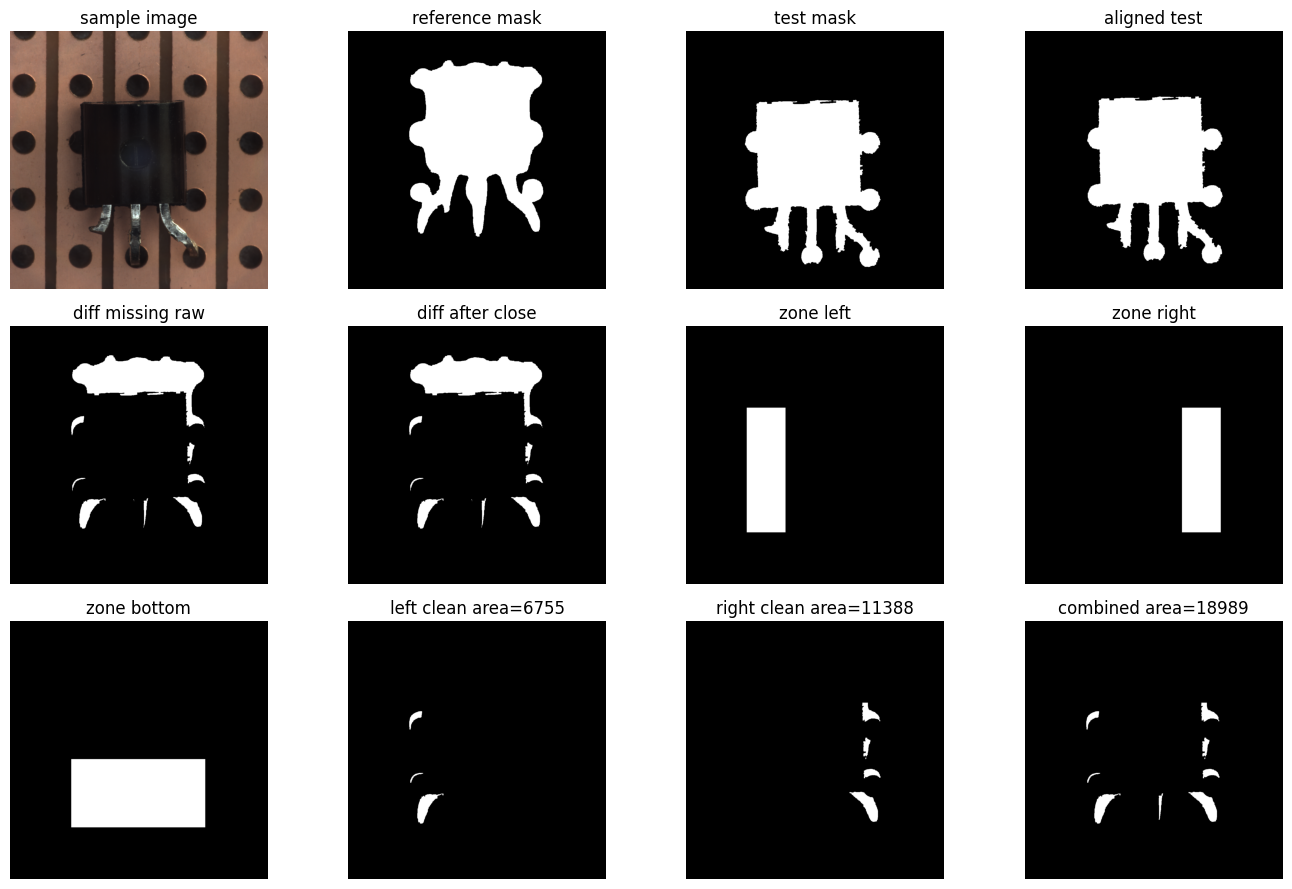

In [15]:
dbg = run_single(sample_img)
print(
    "Sample decision:",
    dbg["decision"],
    "reason:",
    dbg.get("reason", "ok"),
    "area:",
    dbg.get("defect_area", -1),
    "zone_areas:",
    dbg.get("zone_areas", {}),
)

_, axes = plt.subplots(3, 4, figsize=(14, 9))
axes = axes.ravel()

axes[0].imshow(sample_img)
axes[0].set_title("sample image")
axes[0].axis("off")

axes[1].imshow(dbg["ref_mask"], cmap="gray", vmin=0, vmax=255)
axes[1].set_title("reference mask")
axes[1].axis("off")

axes[2].imshow(dbg["test_mask"], cmap="gray", vmin=0, vmax=255)
axes[2].set_title("test mask")
axes[2].axis("off")

axes[3].imshow(dbg["aligned_test_mask"], cmap="gray", vmin=0, vmax=255)
axes[3].set_title("aligned test")
axes[3].axis("off")

axes[4].imshow(dbg["diff_missing_raw"], cmap="gray", vmin=0, vmax=255)
axes[4].set_title("diff missing raw")
axes[4].axis("off")

axes[5].imshow(dbg["diff_missing"], cmap="gray", vmin=0, vmax=255)
axes[5].set_title("diff after close")
axes[5].axis("off")

axes[6].imshow(dbg["zone_masks"]["left_lead"], cmap="gray", vmin=0, vmax=255)
axes[6].set_title("zone left")
axes[6].axis("off")

axes[7].imshow(dbg["zone_masks"]["right_lead"], cmap="gray", vmin=0, vmax=255)
axes[7].set_title("zone right")
axes[7].axis("off")

axes[8].imshow(dbg["zone_masks"]["bottom"], cmap="gray", vmin=0, vmax=255)
axes[8].set_title("zone bottom")
axes[8].axis("off")

axes[9].imshow(dbg["zone_diffs_clean"]["left_lead"], cmap="gray", vmin=0, vmax=255)
axes[9].set_title(f"left clean area={dbg['zone_areas'].get('left_lead', 0)}")
axes[9].axis("off")

axes[10].imshow(dbg["zone_diffs_clean"]["right_lead"], cmap="gray", vmin=0, vmax=255)
axes[10].set_title(f"right clean area={dbg['zone_areas'].get('right_lead', 0)}")
axes[10].axis("off")

axes[11].imshow(dbg["diff_filtered"], cmap="gray", vmin=0, vmax=255)
axes[11].set_title(f"combined area={dbg.get('defect_area', 0)}")
axes[11].axis("off")

plt.tight_layout()
plt.show()

## 7. Add Basic Assertions and Unit-Style Checks
Quick sanity checks for key invariants and failure cases.

In [16]:
assert REFERENCE_MASK.ndim == 2, "Reference mask must be 2D."
assert REFERENCE_MASK.dtype == np.uint8, "Reference mask must be uint8."
assert sample_img.ndim == 3 and sample_img.shape[2] == 3, "Sample image must be RGB."

zones_test = build_multi_zone_masks(
    REFERENCE_MASK,
    side_fraction=LEAD_SIDE_FRACTION,
    top_fraction=LEAD_TOP_FRACTION,
    bottom_fraction=LEAD_BOTTOM_FRACTION,
    bottom_band_top_fraction=LEAD_BOTTOM_BAND_TOP_FRACTION,
)
assert np.count_nonzero(zones_test["left_lead"]) > 0, "left zone cannot be empty."
assert np.count_nonzero(zones_test["right_lead"]) > 0, "right zone cannot be empty."
assert np.count_nonzero(zones_test["bottom"]) > 0, "bottom zone cannot be empty."

aligned_test, align_info = align_by_centroid_translation(
    REFERENCE_MASK,
    ensure_binary_mask(model._extract_transistor_mask(sample_img)),
    MAX_ALIGNMENT_SHIFT_PX,
)
assert aligned_test.shape == REFERENCE_MASK.shape, "Aligned mask must keep mask shape."
assert "reason" in align_info, "Alignment debug must include reason."
print("Basic assertions passed.")

Basic assertions passed.


## Evaluation Utilities
Evaluate binary cut_lead classification and tune area threshold.

In [17]:
@dataclass
class CutLeadRecord:
    cls_name: str
    image_path: Path
    true_cut_lead: bool
    predicted_cut_lead: bool
    defect_area: int
    region_triggered: str
    zone_areas: dict[str, int]
    reason: str


def confusion_from_records(records: list[CutLeadRecord]) -> dict[str, float]:
    """Compute binary metrics for cut_lead target class."""
    tp = sum(r.true_cut_lead and r.predicted_cut_lead for r in records)
    fp = sum((not r.true_cut_lead) and r.predicted_cut_lead for r in records)
    tn = sum((not r.true_cut_lead) and (not r.predicted_cut_lead) for r in records)
    fn = sum(r.true_cut_lead and (not r.predicted_cut_lead) for r in records)

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2.0 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    accuracy = (tp + tn) / max(len(records), 1)

    fp_good = sum((r.cls_name == "good") and r.predicted_cut_lead for r in records)
    cut_total = sum(r.true_cut_lead for r in records)
    fn_cut = fn
    recall_cut = 1.0 - (fn_cut / cut_total) if cut_total else 0.0

    return {
        "tp": float(tp),
        "fp": float(fp),
        "tn": float(tn),
        "fn": float(fn),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "accuracy": float(accuracy),
        "fp_good": float(fp_good),
        "fn_cut": float(fn_cut),
        "recall_cut": float(recall_cut),
    }


def evaluate_test_set(
    min_defect_area_px: int = MIN_DEFECT_AREA_PX,
    component_min_area_px: int = COMPONENT_MIN_AREA_PX,
    lead_side_fraction: float = LEAD_SIDE_FRACTION,
    lead_top_fraction: float = LEAD_TOP_FRACTION,
    morph_close_kernel: int = MORPH_CLOSE_KERNEL,
    morph_open_kernel: int = MORPH_OPEN_KERNEL,
    class_names: Optional[list[str]] = None,
) -> tuple[list[CutLeadRecord], dict[str, float]]:
    """Run detector over full test set and return records with metrics."""
    records: list[CutLeadRecord] = []
    selected_classes = EVAL_CLASS_NAMES if class_names is None else class_names

    for cls_name, image_path in iter_test_images(TEST_DIR, selected_classes):
        img = load_rgb(image_path)
        predicted, debug = safe_is_cut_lead(
            img,
            min_defect_area_px=min_defect_area_px,
            component_min_area_px=component_min_area_px,
            lead_side_fraction=lead_side_fraction,
            lead_top_fraction=lead_top_fraction,
            morph_close_kernel=morph_close_kernel,
            morph_open_kernel=morph_open_kernel,
        )
        records.append(
            CutLeadRecord(
                cls_name=cls_name,
                image_path=image_path,
                true_cut_lead=(cls_name == TARGET_CLASS),
                predicted_cut_lead=bool(predicted),
                defect_area=int(debug.get("defect_area", 0)),
                region_triggered=str(debug.get("region_triggered", "none")),
                zone_areas=dict(debug.get("zone_areas", {})),
                reason=str(debug.get("reason", "ok")),
            )
        )

    return records, confusion_from_records(records)


def sweep_parameters(
    min_defect_area_values: tuple[int, ...] = (60, 90, 120),
    component_min_area_values: tuple[int, ...] = (12, 20, 30),
    lead_side_fraction_values: tuple[float, ...] = (0.22, 0.28, 0.34),
    lead_top_fraction_values: tuple[float, ...] = (0.24, 0.30, 0.36),
    morph_close_kernel_values: tuple[int, ...] = (3,),
    morph_open_kernel_values: tuple[int, ...] = (3,),
) -> tuple[dict[str, float], dict[str, float], list[dict[str, float]]]:
    """Grid-search selected parameters and select by cut recall first, then F1."""
    history: list[dict[str, float]] = []
    best_params: Optional[dict[str, float]] = None
    best_metrics: Optional[dict[str, float]] = None

    for min_area in min_defect_area_values:
        for comp_area in component_min_area_values:
            for side_frac in lead_side_fraction_values:
                for top_frac in lead_top_fraction_values:
                    for close_k in morph_close_kernel_values:
                        for open_k in morph_open_kernel_values:
                            _, metrics = evaluate_test_set(
                                min_defect_area_px=min_area,
                                component_min_area_px=comp_area,
                                lead_side_fraction=side_frac,
                                lead_top_fraction=top_frac,
                                morph_close_kernel=close_k,
                                morph_open_kernel=open_k,
                            )

                            row = {
                                "min_defect_area_px": float(min_area),
                                "component_min_area_px": float(comp_area),
                                "lead_side_fraction": float(side_frac),
                                "lead_top_fraction": float(top_frac),
                                "morph_close_kernel": float(close_k),
                                "morph_open_kernel": float(open_k),
                                "precision": float(metrics["precision"]),
                                "recall": float(metrics["recall"]),
                                "f1": float(metrics["f1"]),
                                "accuracy": float(metrics["accuracy"]),
                                "tp": float(metrics["tp"]),
                                "fp": float(metrics["fp"]),
                                "tn": float(metrics["tn"]),
                                "fn": float(metrics["fn"]),
                                "fp_good": float(metrics["fp_good"]),
                                "recall_cut": float(metrics["recall_cut"]),
                            }
                            history.append(row)

                            if best_metrics is None:
                                best_metrics = metrics
                                best_params = {
                                    "min_defect_area_px": float(min_area),
                                    "component_min_area_px": float(comp_area),
                                    "lead_side_fraction": float(side_frac),
                                    "lead_top_fraction": float(top_frac),
                                    "morph_close_kernel": float(close_k),
                                    "morph_open_kernel": float(open_k),
                                }
                                continue

                            candidate_score = (metrics["recall_cut"], metrics["f1"], -metrics["fp_good"])
                            best_score = (best_metrics["recall_cut"], best_metrics["f1"], -best_metrics["fp_good"])
                            if candidate_score > best_score:
                                best_metrics = metrics
                                best_params = {
                                    "min_defect_area_px": float(min_area),
                                    "component_min_area_px": float(comp_area),
                                    "lead_side_fraction": float(side_frac),
                                    "lead_top_fraction": float(top_frac),
                                    "morph_close_kernel": float(close_k),
                                    "morph_open_kernel": float(open_k),
                                }

    if best_params is None or best_metrics is None:
        raise RuntimeError("Sweep produced no results.")

    return best_params, best_metrics, history


def show_cases(
    records: list[CutLeadRecord],
    mode: str,
    max_items: int = 6,
    detector_kwargs: Optional[dict[str, float]] = None,
) -> None:
    """Visualize FP or FN cases with detector masks and per-zone diagnostics."""
    if mode not in {"fp", "fn"}:
        raise ValueError("mode must be 'fp' or 'fn'.")

    if mode == "fp":
        selected = [r for r in records if (not r.true_cut_lead) and r.predicted_cut_lead]
    else:
        selected = [r for r in records if r.true_cut_lead and (not r.predicted_cut_lead)]

    selected = selected[:max_items]
    if not selected:
        print("No", mode.upper(), "cases to display.")
        return

    kwargs = detector_kwargs or {}

    _, axes = plt.subplots(len(selected), 3, figsize=(11, 3.3 * len(selected)))
    if len(selected) == 1:
        axes = np.array([axes])

    for i, rec in enumerate(selected):
        img = load_rgb(rec.image_path)
        _, dbg_local = is_cut_lead(img, return_debug=True, **kwargs)

        zone_areas = dbg_local.get("zone_areas", {})
        zone_text = ", ".join(f"{k}:{v}" for k, v in zone_areas.items())

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{rec.cls_name} {rec.image_path.name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(dbg_local["diff_missing"], cmap="gray", vmin=0, vmax=255)
        axes[i, 1].set_title(f"reason={dbg_local.get('reason', 'ok')}")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(dbg_local["diff_filtered"], cmap="gray", vmin=0, vmax=255)
        axes[i, 2].set_title(
            f"area={dbg_local.get('defect_area', 0)}\n{zone_text}"
        )
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

## 8. Persist Outputs and Debug Logs
Save sweep metrics and final records for later comparison.

In [ ]:
import csv

best_params, best_metrics, sweep_hist = sweep_parameters()
print("Best params:", best_params)
print("Best metrics:", best_metrics)

records, final_metrics = evaluate_test_set(
    min_defect_area_px=int(best_params["min_defect_area_px"]),
    component_min_area_px=int(best_params["component_min_area_px"]),
    lead_side_fraction=float(best_params["lead_side_fraction"]),
    lead_top_fraction=float(best_params["lead_top_fraction"]),
    morph_close_kernel=int(best_params["morph_close_kernel"]),
    morph_open_kernel=int(best_params["morph_open_kernel"]),
)
print("Final metrics at best params:", final_metrics)

show_cases(records, mode="fp", max_items=5, detector_kwargs=best_params)
show_cases(records, mode="fn", max_items=5, detector_kwargs=best_params)

output_dir = PROJECT_DIR / "analysis_outputs"
output_dir.mkdir(exist_ok=True)

csv_path = output_dir / "cut_lead_sweep_metrics_multi_zone.csv"
if sweep_hist:
    fieldnames = list(sweep_hist[0].keys())
    with open(csv_path, "w", newline="", encoding="ascii", errors="ignore") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in sweep_hist:
            writer.writerow(row)

with open(output_dir / "cut_lead_best_metrics_multi_zone.txt", "w", encoding="ascii", errors="ignore") as f:
    f.write("best_params\n")
    for key, value in best_params.items():
        f.write(f"{key}={value}\n")
    f.write("\nfinal_metrics\n")
    for key in [
        "tp",
        "fp",
        "tn",
        "fn",
        "precision",
        "recall",
        "f1",
        "accuracy",
        "fp_good",
        "fn_cut",
        "recall_cut",
    ]:
        f.write(f"{key}={final_metrics[key]}\n")

print("Saved outputs to:", output_dir)